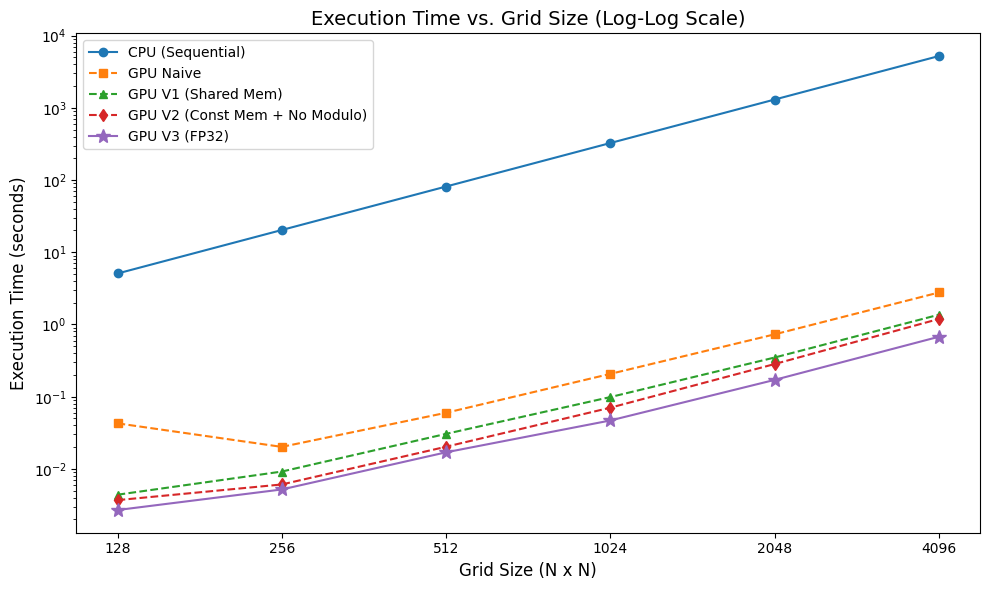

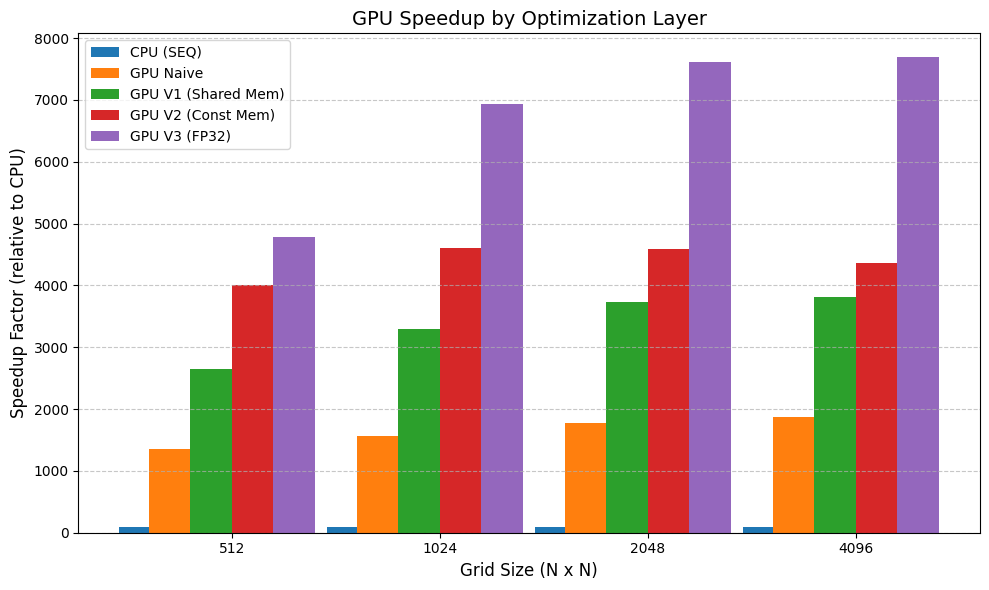

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Tile Size 16
N = np.array([128, 256, 512, 1024, 2048, 4096])
T_seq = np.array([5.0795, 20.3176, 81.2717, 325.1207, 1300.6583, 5203.7136])
T_naive = np.array([0.0428, 0.0202, 0.0599, 0.2071, 0.7305, 2.7718])
T_v1 = np.array([0.0044, 0.0092, 0.0306, 0.0989, 0.3488, 1.3655])
T_v2 = np.array([0.0037, 0.0061, 0.0203, 0.0705, 0.2833, 1.1927])
T_v3 = np.array([0.0027, 0.0052, 0.0170, 0.0469, 0.1710, 0.6765])

# Calculate Speedups relative to CPU
S_naive = T_seq / T_naive
S_v1 = T_seq / T_v1
S_v2 = T_seq / T_v2
S_v3 = T_seq / T_v3

# ---------------------------------------------------------
# Plot 1: Log-Log Execution Time vs. Grid Size
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(N, T_seq, marker='o', linestyle='-', label='CPU (Sequential)')
plt.plot(N, T_naive, marker='s', linestyle='--', label='GPU Naive')
plt.plot(N, T_v1, marker='^', linestyle='--', label='GPU V1 (Shared Mem)')
plt.plot(N, T_v2, marker='d', linestyle='--', label='GPU V2 (Const Mem + No Modulo)')
plt.plot(N, T_v3, marker='*', linestyle='-', markersize=10, label='GPU V3 (FP32)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Grid Size (N x N)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.title('Execution Time vs. Grid Size (Log-Log Scale)', fontsize=14)
plt.xticks(N, [str(n) for n in N])
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('execution_time_loglog.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 2: Grouped Bar Chart of Speedups (for N >= 512)
# ---------------------------------------------------------
# Filter for larger grid sizes where GPU saturation is visible
large_indices = [2, 3, 4, 5] # Corresponds to N = 512, 1024, 2048, 4096
N_large = N[large_indices]

x = np.arange(len(N_large))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 2.2*width, 100, width, label='CPU (SEQ)')
plt.bar(x - 1.5*width, S_naive[large_indices], width, label='GPU Naive')
plt.bar(x - 0.5*width, S_v1[large_indices], width, label='GPU V1 (Shared Mem)')
plt.bar(x + 0.5*width, S_v2[large_indices], width, label='GPU V2 (Const Mem)')
plt.bar(x + 1.5*width, S_v3[large_indices], width, label='GPU V3 (FP32)')

plt.xlabel('Grid Size (N x N)', fontsize=12)
plt.ylabel('Speedup Factor (relative to CPU)', fontsize=12)
plt.title('GPU Speedup by Optimization Layer', fontsize=14)
plt.xticks(x, [str(n) for n in N_large])
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('speedup_barchart.png', dpi=300)
plt.show()

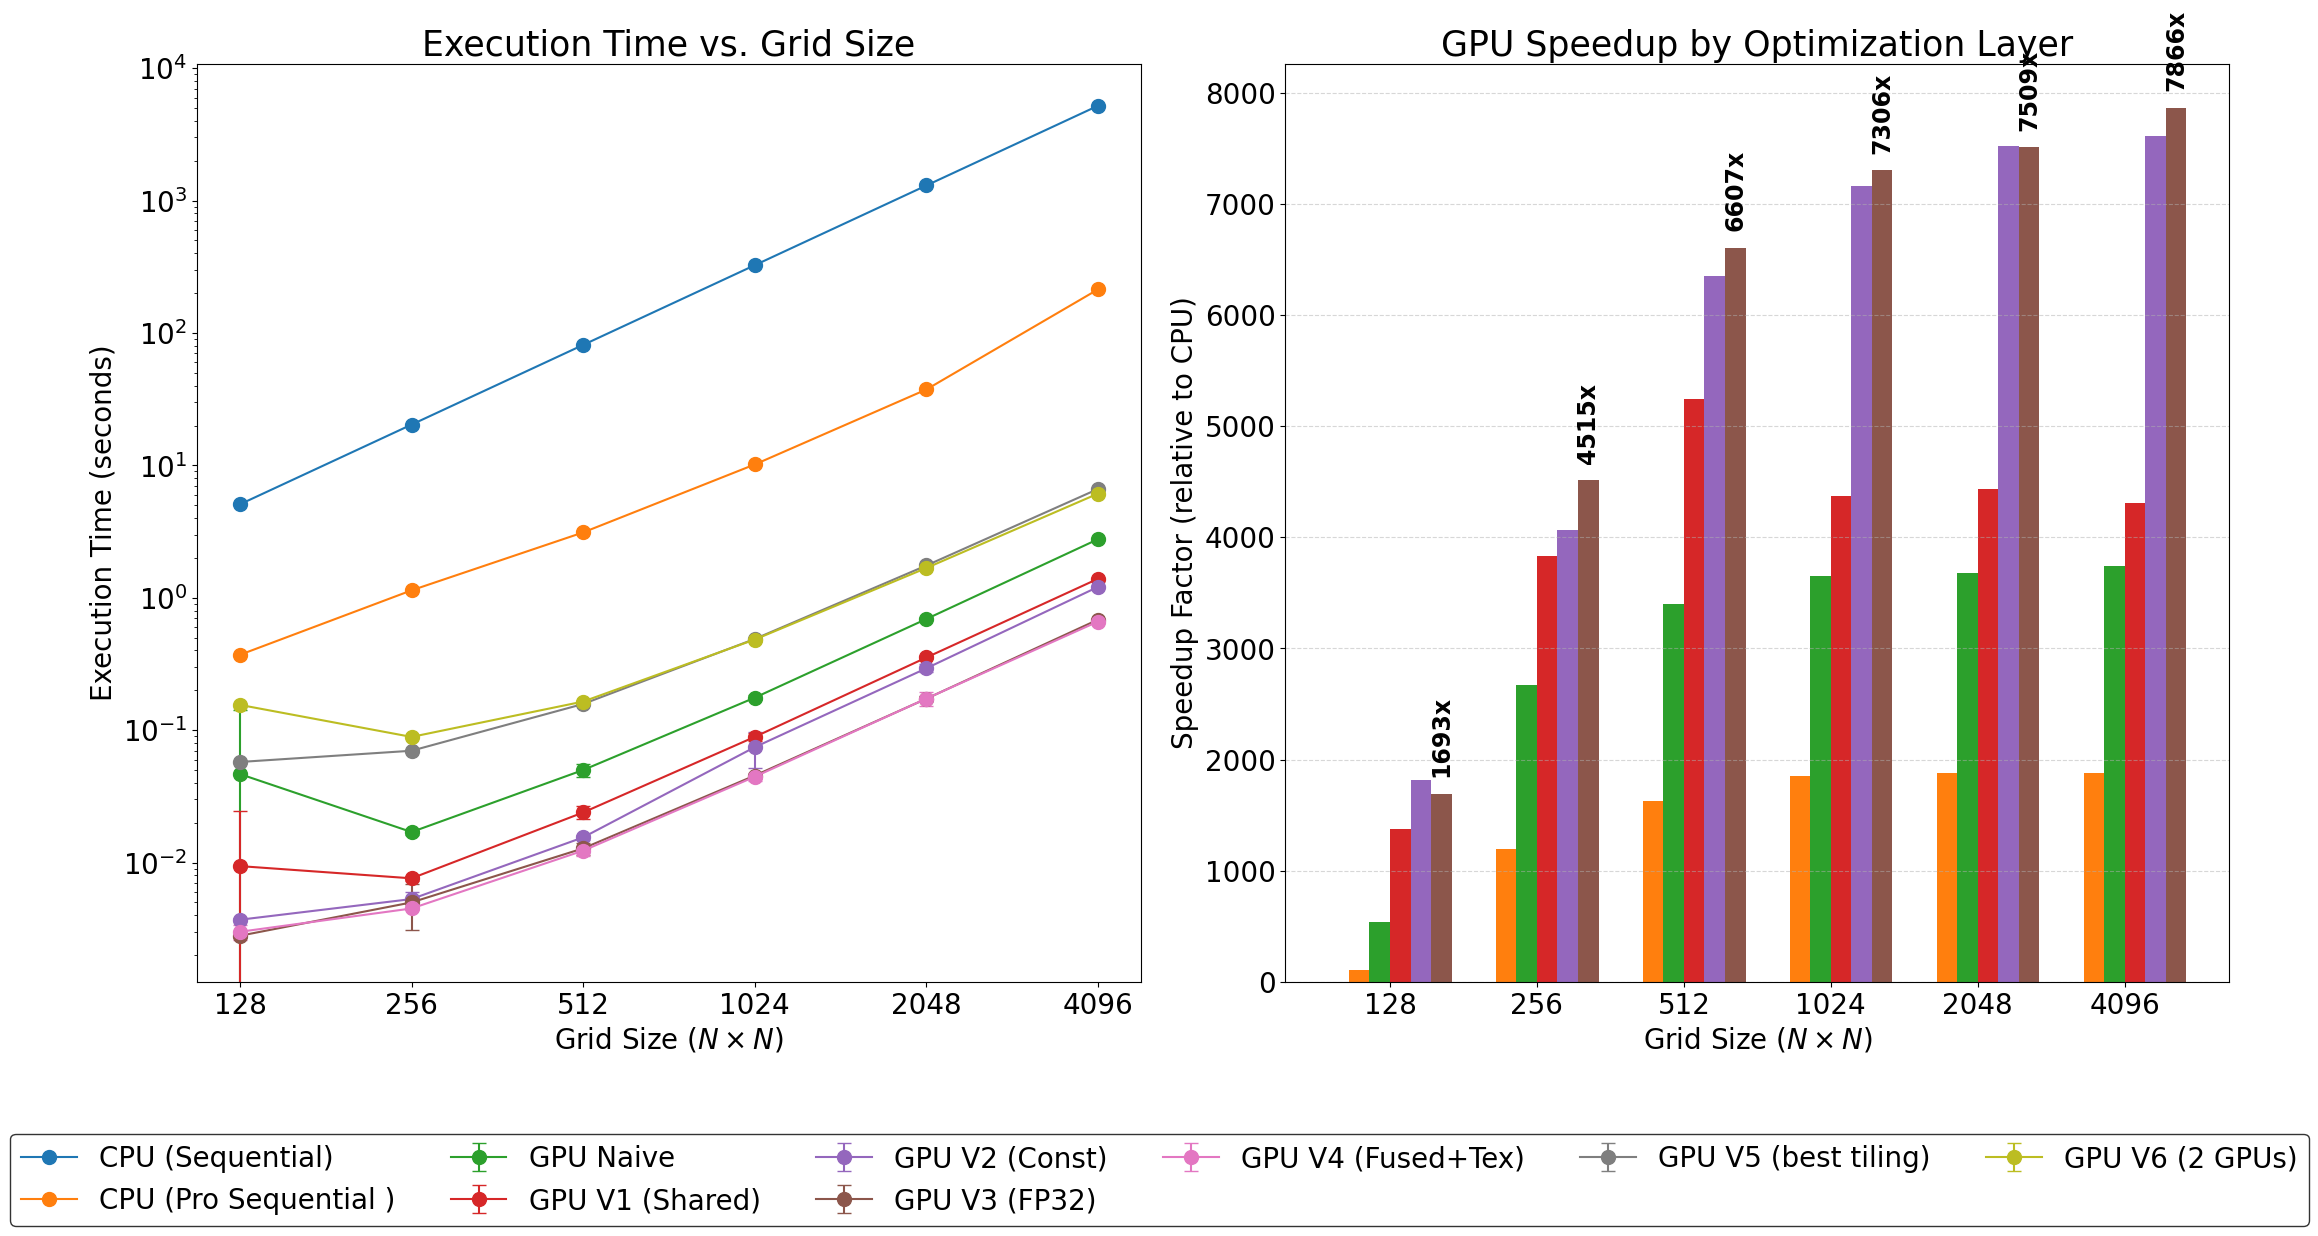

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Increase default font sizes globally
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 25,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})

# Data from the provided Table (N x N grid sizes)
N = np.array([128, 256, 512, 1024, 2048, 4096])
T_seq = np.array([5.0795, 20.3176, 81.2717, 325.1207, 1300.6583, 5203.7136])

# Means (Time in seconds)

# Means (Time in seconds)
T_naive = np.array([0.0466, 0.0170, 0.0500, 0.1760, 0.6915, 2.7695])
T_seq_v2 = np.array([0.3708, 1.1379, 3.1160, 10.1602, 37.4408, 213.4900])
T_v1 = np.array([0.0094, 0.0076, 0.0239, 0.0890, 0.3539, 1.3920])
T_v2 = np.array([0.0037, 0.0053, 0.0155, 0.0744, 0.2934, 1.2082])
T_v3 = np.array([0.0028, 0.0050, 0.0128, 0.0454, 0.1729, 0.6839])
T_v4 = np.array([0.0030, 0.0045, 0.0123, 0.0445, 0.1732, 0.6615])
T_v5 = np.array([0.0575, 0.0699, 0.1577, 0.4885, 1.7527, 6.6339])
T_v6 = np.array([0.1552, 0.0889, 0.1645, 0.4838, 1.6791, 6.1210])


# Standard Deviations (Uncertainty)
std_naive = np.array([0.0961, 0.0008, 0.0057, 0.0072, 0.0103, 0.0163])
std_v1 = np.array([0.0152, 0.0003, 0.0027, 0.0061, 0.0108, 0.0069])
std_v2 = np.array([0.0001, 0.0007, 0.0007, 0.0226, 0.0207, 0.0033])
std_v3 = np.array([0.0001, 0.0019, 0.0013, 0.0012, 0.0068, 0.0028])
std_v4 = np.array([0.0004, 0.0001, 0.0011, 0.0029, 0.0200, 0.0035])

# Calculate Speedups relative to CPU Sequential
S_naive = T_seq / T_naive
S_v1 = T_seq / T_v1
S_v2 = T_seq / T_v2
S_v3 = T_seq / T_v3
S_v4 = T_seq / T_v4

# Indices for bar chart (grid sizes where GPU performance saturates)
large_indices = [0, 1, 2, 3, 4, 5] # N = 512, 1024, 2048, 4096
N_large = N[large_indices]

# Setup Plotting Frame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 12))

# ---------------------------------------------------------
# Plot 1: Log-Log Execution Time vs. Grid Size (Left)
# ---------------------------------------------------------
ax1.errorbar(N, T_seq, fmt='-o', label='CPU (Sequential)', markersize=10, capsize=5)
ax1.errorbar(N, T_seq_v2, fmt='-o', label='CPU (Pro Sequential )', markersize=10, capsize=5)
ax1.errorbar(N, T_naive, yerr=std_naive, fmt='-o', label='GPU Naive', markersize=10, capsize=5)
ax1.errorbar(N, T_v1, yerr=std_v1, fmt='-o', label='GPU V1 (Shared)', markersize=10, capsize=5)
ax1.errorbar(N, T_v2, yerr=std_v2, fmt='-o', label='GPU V2 (Const)', markersize=10, capsize=5)
ax1.errorbar(N, T_v3, yerr=std_v3, fmt='-o', label='GPU V3 (FP32)', markersize=10, capsize=5)
ax1.errorbar(N, T_v4, yerr=std_v4, fmt='-o', label='GPU V4 (Fused+Tex)', markersize=10, capsize=5)
ax1.errorbar(N, T_v5, yerr=std_v4, fmt='-o', label='GPU V5 (best tiling)', markersize=10, capsize=5)
ax1.errorbar(N, T_v6, yerr=std_v4, fmt='-o', label='GPU V6 (2 GPUs)', markersize=10, capsize=5)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.set_xlabel('Grid Size ($N \\times N$)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time vs. Grid Size')
ax1.set_xticks(N)
ax1.set_xticklabels([str(n) for n in N])
#ax1.grid(True, which="both", linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Plot 2: Grouped Bar Chart of Speedups (Right)
# ---------------------------------------------------------
x = np.arange(len(N_large))
width = 0.14 # Grouped bar width

ax2.bar(x - 2.5*width, 1, width, label='CPU (Sequential)')
ax2.bar(x - 1.5*width, S_naive[large_indices], width, label='GPU Naive')
ax2.bar(x - 0.5*width, S_v1[large_indices], width, label='GPU V1 (Shared)')
ax2.bar(x + 0.5*width, S_v2[large_indices], width, label='GPU V2 (Const)')
ax2.bar(x + 1.5*width, S_v3[large_indices], width, label='GPU V3 (FP32)')
ax2.bar(x + 2.5*width, S_v4[large_indices], width, label='GPU V4 (Fused+Exp)')

ax2.set_xlabel('Grid Size ($N \\times N$)')
ax2.set_ylabel('Speedup Factor (relative to CPU)')
ax2.set_title('GPU Speedup by Optimization Layer')
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in N_large])
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: Add numeric text labels to the top of the v4 bars for emphasis
for i, val in enumerate(S_v4[large_indices]):
    ax2.text(x[i] + 2.5*width, val + 150, f'{int(val)}x', 
             ha='center', va='bottom', rotation=90, fontsize=17, fontweight='bold')

# Single Shared Legend Box
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=6, frameon=True, edgecolor='black', fancybox=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('performance_v4_comparison.png', dpi=300)
plt.show()

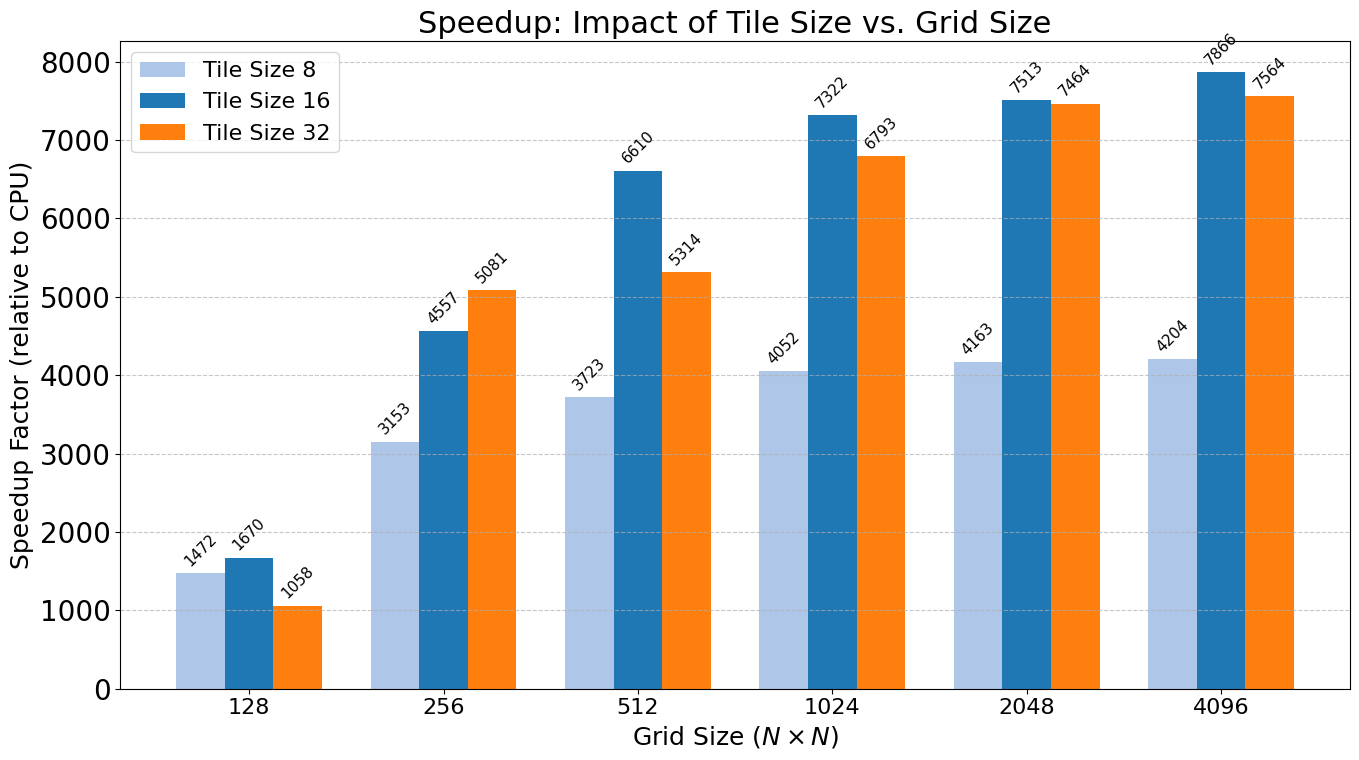

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction from the provided tables (v4 Speedup values)
N_labels = ['128', '256', '512', '1024', '2048', '4096']
S_v4_tile8 = [1472.12, 3153.43, 3723.12, 4052.11, 4163.95, 4204.24]
S_v4_tile16 = [1670.89, 4557.75, 6610.68, 7322.62, 7513.91, 7866.53]
S_v4_tile32 = [1058.81, 5081.45, 5314.11, 6793.61, 7464.55, 7564.73]

# Setup for the grouped bar chart
x = np.arange(len(N_labels))  # label locations
width = 0.25  # width of individual bars

fig, ax = plt.subplots(figsize=(14, 8))

# Define colors
colors = ['#aec7e8', '#1f77b4', '#ff7f0e']

# Plot bars for each tile size
rects1 = ax.bar(x - width, S_v4_tile8, width, label='Tile Size 8', color=colors[0])
rects2 = ax.bar(x, S_v4_tile16, width, label='Tile Size 16', color=colors[1])
rects3 = ax.bar(x + width, S_v4_tile32, width, label='Tile Size 32', color=colors[2])

# Add text for labels, title and axis tick labels
ax.set_xlabel('Grid Size ($N \\times N$)', fontsize=18)
ax.set_ylabel('Speedup Factor (relative to CPU)', fontsize=18)
ax.set_title('Speedup: Impact of Tile Size vs. Grid Size', fontsize=22)
ax.set_xticks(x)
ax.set_xticklabels(N_labels, fontsize=16)
ax.legend(fontsize=16)

# Add grid lines for readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Helper function to add numeric labels on top of bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, rotation=45)

# Label the bars
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig('v4_speedup_vs_tile_size.png', dpi=300)
plt.show()

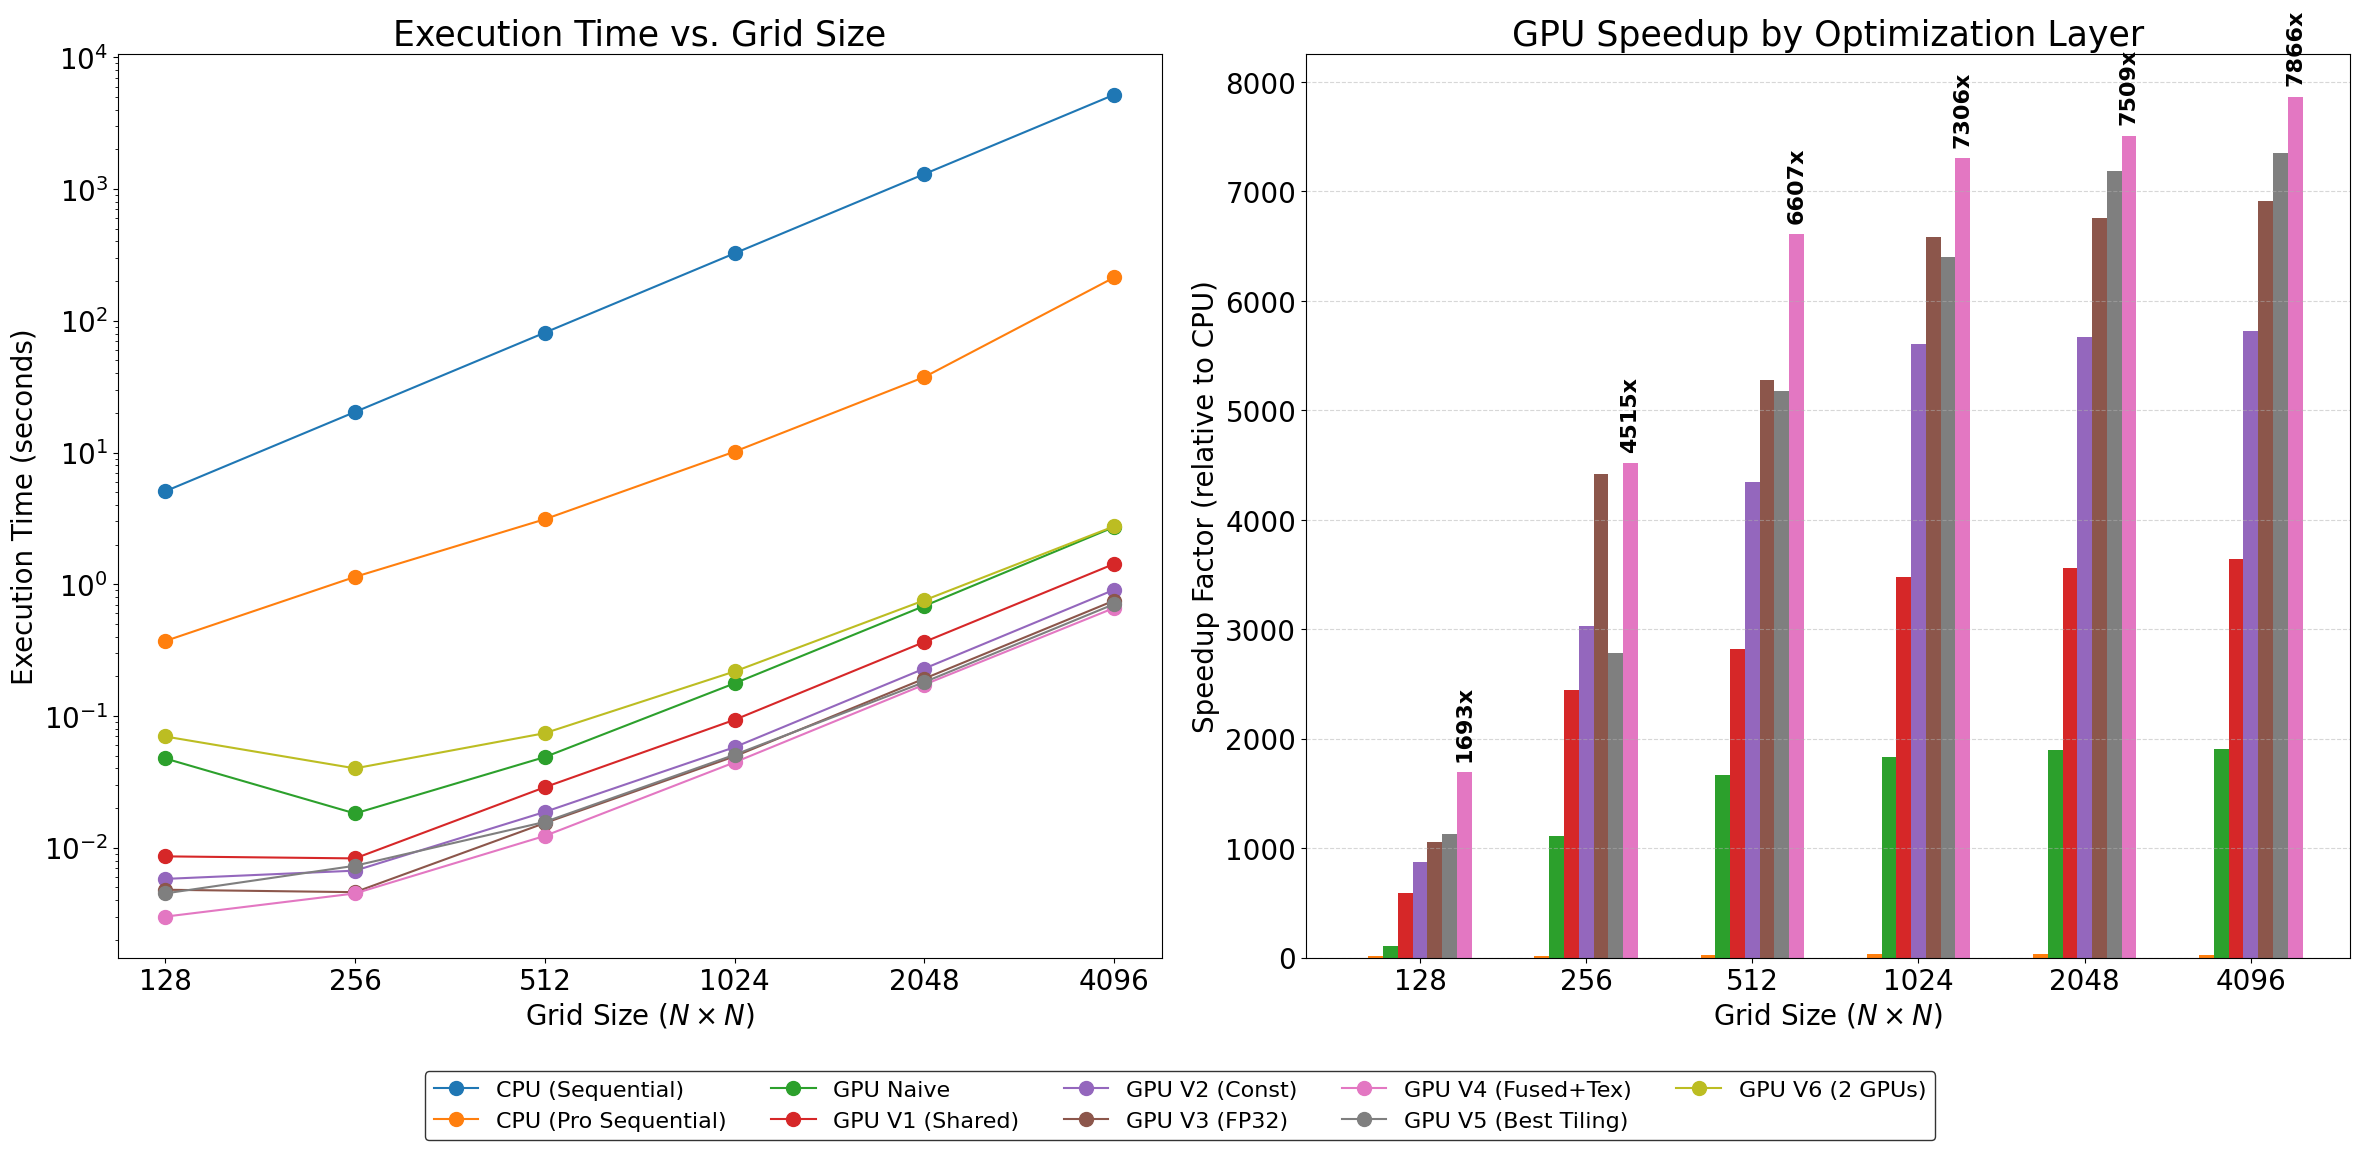

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Increase default font sizes globally
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 25,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 16
})

# Grid sizes
N = np.array([128, 256, 512, 1024, 2048, 4096])
# Baseline CPU Sequential Time
T_seq = np.array([5.0795, 20.3176, 81.2717, 325.1207, 1300.6583, 5203.7136])


# Means (Time in seconds)
T_seq_v2 = np.array([0.3708, 1.1379, 3.1160, 10.1602, 37.4408, 213.4900])
T_naive  = np.array([0.0476, 0.0182, 0.0488, 0.1771, 0.6852, 2.7226])
T_v1     = np.array([0.0086, 0.0083, 0.0288, 0.0936, 0.3652, 1.4287])
T_v2     = np.array([0.0058, 0.0067, 0.0187, 0.0580, 0.2293, 0.9090])
T_v3     = np.array([0.0048, 0.0046, 0.0154, 0.0494, 0.1924, 0.7523])
T_v4 = np.array([0.0030, 0.0045, 0.0123, 0.0445, 0.1732, 0.6615])
T_v5     = np.array([0.0045, 0.0073, 0.0157, 0.0508, 0.1810, 0.7075])
T_v6 = 3/2 * (0.0466 / 0.1552) * np.array([0.1552, 0.0889, 0.1645, 0.4838, 1.6791, 6.1210])



# Calculate Speedups relative to CPU Sequential baseline
S_seq_v2 = T_seq / T_seq_v2
S_naive = T_seq / T_naive
S_v1 = T_seq / T_v1
S_v2 = T_seq / T_v2
S_v3 = T_seq / T_v3
S_v4 = T_seq / T_v4
S_v5 = T_seq / T_v5
S_v6 = T_seq / T_v6

# Setup Plotting Frame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# --- Plot 1: Log-Log Execution Time vs. Grid Size ---
ax1.plot(N, T_seq, '-o', label='CPU (Sequential)', markersize=10)
ax1.plot(N, T_seq_v2, '-o', label='CPU (Pro Sequential)', markersize=10)
ax1.plot(N, T_naive, '-o', label='GPU Naive', markersize=10)
ax1.plot(N, T_v1, '-o', label='GPU V1 (Shared)', markersize=10)
ax1.plot(N, T_v2, '-o', label='GPU V2 (Const)', markersize=10)
ax1.plot(N, T_v3, '-o', label='GPU V3 (FP32)', markersize=10)
ax1.plot(N, T_v4, '-o', label='GPU V4 (Fused+Tex)', markersize=10)
ax1.plot(N, T_v5, '-o', label='GPU V5 (Best Tiling)', markersize=10)
ax1.plot(N, T_v6, '-o', label='GPU V6 (2 GPUs)', markersize=10)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.set_xlabel('Grid Size ($N \\times N$)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time vs. Grid Size')
ax1.set_xticks(N)
ax1.set_xticklabels([str(n) for n in N])

# --- Plot 2: Grouped Bar Chart of Speedups ---
x = np.arange(len(N))
n_bars = 9
width = 0.8 / n_bars
offsets = np.arange(n_bars) - (n_bars - 1) / 2

ax2.bar(x + offsets[0]*width, 1, width, label='CPU (Sequential)')
ax2.bar(x + offsets[1]*width, S_seq_v2, width, label='CPU (Pro Sequential)')
ax2.bar(x + offsets[2]*width, S_naive, width, label='GPU Naive')
ax2.bar(x + offsets[3]*width, S_v1, width, label='GPU V1 (Shared)')
ax2.bar(x + offsets[4]*width, S_v2, width, label='GPU V2 (Const)')
ax2.bar(x + offsets[5]*width, S_v3, width, label='GPU V3 (FP32)')
ax2.bar(x + offsets[7]*width, S_v4, width, label='GPU V4 (Fused+Exp)')
ax2.bar(x + offsets[6]*width, S_v5, width, label='GPU V5 (Best Tiling)')

ax2.set_xlabel('Grid Size ($N \\times N$)')
ax2.set_ylabel('Speedup Factor (relative to CPU)')
ax2.set_title('GPU Speedup by Optimization Layer')
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in N])
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Text labels for the highest speedup (V3)
for i, val in enumerate(S_v4):
    ax2.text(x[i] + offsets[7]*width, val + 100, f'{int(val)}x', 
             ha='center', va='bottom', rotation=90, fontsize=16, fontweight='bold')

# Single Shared Legend Box
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.1), 
           ncol=5, frameon=True, edgecolor='black', fancybox=True)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('performance_all_versions_comparison.png', dpi=300)